In [2]:
import pandas as pd

# Took combine dataset and filtered for runningbacks over a 5 year span
combine = pd.read_csv("NFL_Combine_Since_2000.csv")

rb_df = combine[combine["Position"] == "RB"]

rb_17_p = rb_df[rb_df["Year"] >= 2017]

rb_17_22 = rb_17_p[rb_17_p["Year"] <= 2022]

combine_rb = rb_17_22.drop_duplicates(subset="Player")

# Took rushing data and filtered over those same 5 years
rushing = pd.read_csv("rushing_cleaned.csv")

rush_17_p = rushing[rushing["Year"] >= 2017]

rush_17_22 = rush_17_p[rush_17_p["Year"] <= 2022]

# Took a summary of rushing statistics of those given players
rush_summary = rush_17_22.groupby("Player").agg({
    "rYds": "mean",
    "rY/A": "mean",
    "rTD": "mean"
}).reset_index()

# combined combine data with the rushing stats for those 5 years 
final_df = combine_rb.merge(rush_summary, on="Player", how="inner")
final_clean = final_df[[
    "Player",
    "Height",
    "Weight",
    "40-yd Dash",
    "Vertical Jump",
    "Bench Press",
    "Broad Jump",
    "3-Cone Drill",
    "20-yd Shuttle",
    "rYds",
    "rY/A",
    "rTD"
]]


MAE: 296.54701666666654
R2: -0.6451715477665969
         Feature  Importance
2     40-yd Dash    0.191231
7  20-yd Shuttle    0.176887
1         Weight    0.157908
4    Bench Press    0.139742
5     Broad Jump    0.108355
6   3-Cone Drill    0.095951
3  Vertical Jump    0.082435
0         Height    0.047490


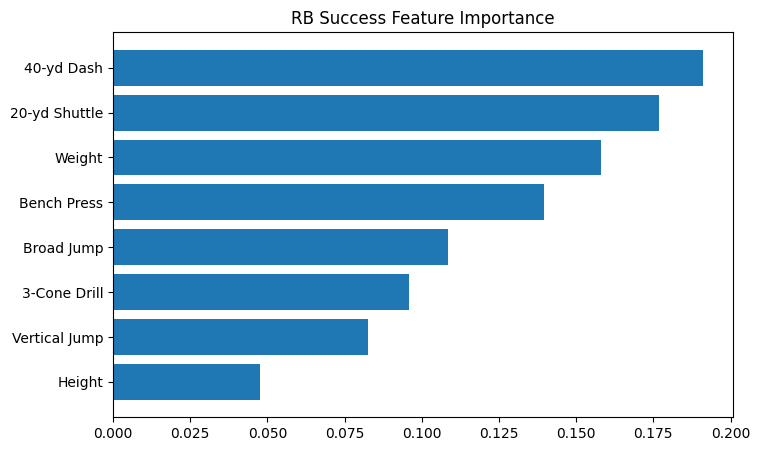

In [3]:
from sklearn.model_selection import train_test_split

# Create copy of dataframe and made combine data the x variables and the y variable rushing yards
df = final_clean.copy()

df = df.dropna()

df = df.drop(columns=["Player"])

X = df.drop(columns=["rYds"])
X = X.drop(columns=["rTD"])
X = X.drop(columns=["rY/A"])
y = df["rYds"]

# Created training and testing data for Model
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model with data of r2 score and error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)


# Plot the results of how much each of the given combine drills effected the rushing yards of those players
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importances["Feature"], importances["Importance"])
plt.gca().invert_yaxis()
plt.title("RB Success Feature Importance")
plt.show()

MAE: 0.7932122062805362
R2: -0.7619614618472474
         Feature  Importance
2     40-yd Dash    0.194515
1         Weight    0.164282
4    Bench Press    0.146823
5     Broad Jump    0.145024
7  20-yd Shuttle    0.137896
6   3-Cone Drill    0.089004
3  Vertical Jump    0.081883
0         Height    0.040574


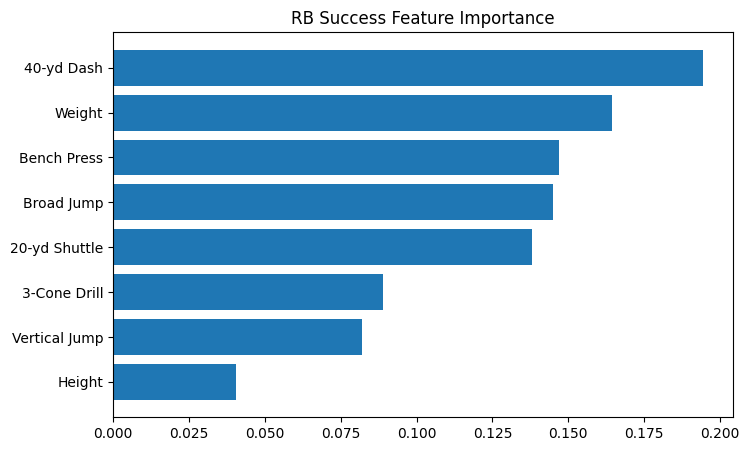

In [4]:
from sklearn.preprocessing import StandardScaler

# Created a "Running Back Score" with a combined totals of TDs, Rushing yards per game, and rushing yards total
scaler = StandardScaler()

df[["rYds_s", "rYA_s", "rTD_s"]] = scaler.fit_transform(
    df[["rYds", "rY/A", "rTD"]]
)

df["RB_score"] = (
    0.5 * df["rYds_s"] +
    0.3 * df["rYA_s"] +
    0.2 * df["rTD_s"]
)
# Created X value and Y values for model
X = df.drop(columns=[
    "rYds", "rY/A", "rTD",
    "rYds_s", "rYA_s", "rTD_s",
    "RB_score"
])

y = df["RB_score"]

# Split testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model for same results but with different Y value being our Running Back Score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

# Plot Scores 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importances["Feature"], importances["Importance"])
plt.gca().invert_yaxis()
plt.title("RB Success Feature Importance")
plt.show()